In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("house_prices.csv")

In [5]:
df.head()

,area_sqft,bedrooms,bathrooms,age_years,price
0,1360,5,1,12,6927344
1,1794,3,2,12,6870877
2,1630,3,3,0,7556143
3,1595,2,2,5,7280571
4,2138,4,2,23,7300954


In [6]:
df.shape

(500, 5)

In [7]:
df.info

<bound method DataFrame.info of      area_sqft  bedrooms  bathrooms  age_years     price
0         1360         5          1         12   6927344
1         1794         3          2         12   6870877
2         1630         3          3          0   7556143
3         1595         2          2          5   7280571
4         2138         4          2         23   7300954
..         ...       ...        ...        ...       ...
495       1709         5          3         24   7254178
496       2945         2          2         10  10139172
497       1133         1          3          4   4896650
498       1656         3          2         14   6391000
499       1738         4          3          4   7862364

[500 rows x 5 columns]>

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area_sqft  500 non-null    int64
 1   bedrooms   500 non-null    int64
 2   bathrooms  500 non-null    int64
 3   age_years  500 non-null    int64
 4   price      500 non-null    int64
dtypes: int64(5)
memory usage: 19.7 KB


In [9]:
df.isnull().sum()

,0
area_sqft,0
bedrooms,0
bathrooms,0
age_years,0
price,0


In [10]:
df.describe()

,area_sqft,bedrooms,bathrooms,age_years,price
count,500.000000,500.00000,500.000000,500.000000,5.000000e+02
mean,1761.738000,3.01400,1.984000,14.954000,6.408804e+06
std,688.450266,1.44983,0.820421,8.990971,2.507253e+06
min,501.000000,1.00000,1.000000,0.000000,5.000000e+05
25%,1183.750000,2.00000,1.000000,7.000000,4.643701e+06
50%,1732.500000,3.00000,2.000000,14.000000,6.553930e+06
75%,2307.000000,4.00000,3.000000,23.000000,8.382600e+06
max,2992.000000,5.00000,3.000000,30.000000,1.301269e+07


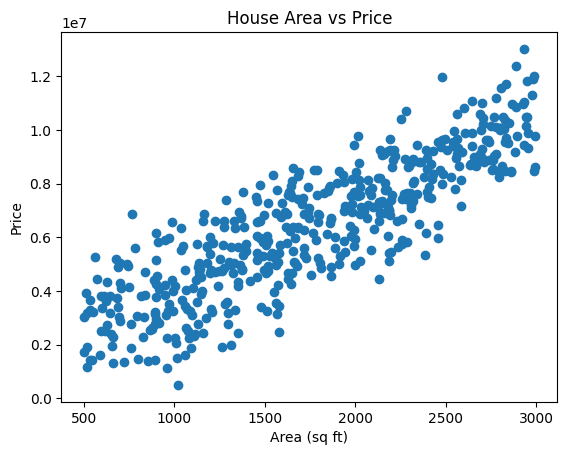

In [14]:
plt.scatter(df['area_sqft'] ,df['price'])
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("House Area vs Price")

plt.show()

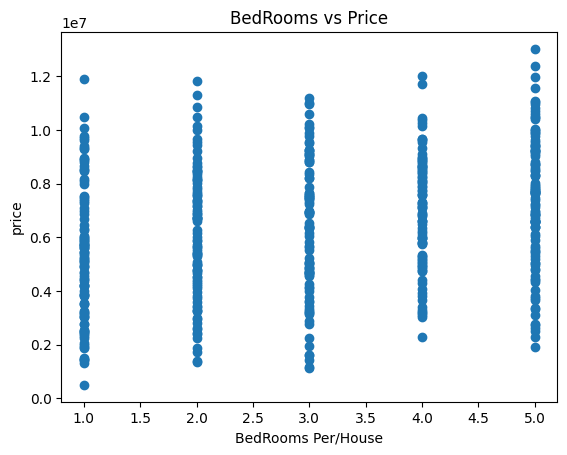

In [15]:
plt.scatter(df['bedrooms'],df['price'])
plt.xlabel("BedRooms Per/House")
plt.ylabel("price")

plt.title("BedRooms vs Price")

plt.show()

<Axes: >

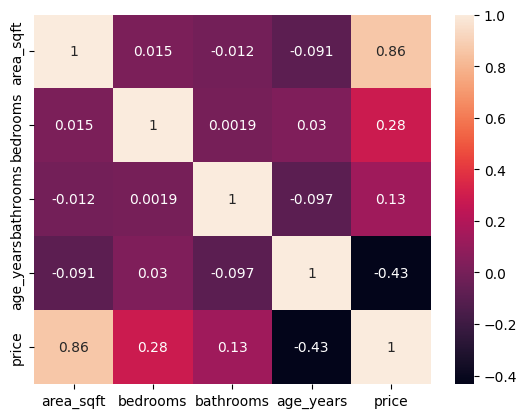

In [18]:
sns.heatmap(df.corr() , annot=True)

In [19]:
df.head()

,area_sqft,bedrooms,bathrooms,age_years,price
0,1360,5,1,12,6927344
1,1794,3,2,12,6870877
2,1630,3,3,0,7556143
3,1595,2,2,5,7280571
4,2138,4,2,23,7300954


In [21]:
X = df[['area_sqft' , 'bedrooms' , 'bathrooms' , 'age_years']]
y = df['price']

In [23]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train , y_train)

LinearRegression()

In [27]:
model.coef_

array([   3013.66922367,  480380.70936841,  340142.81517653,
       -100542.01927583])

In [28]:
model.intercept_

np.float64(486738.71722279675)

In [29]:
predictions = model.predict(X_test)

In [31]:
predictions[:10]


array([ 2293959.9841495 ,  3643941.02880507,  3984206.00809594,
        5223800.21978363, 11342012.62170802,  8867183.63956709,
        8665866.86519615, 10678513.52122035,  7092534.36983354,
        8643856.80290446])

In [32]:
y_test[:10]

,price
361,2551339
73,3602200
374,3735900
155,5683051
104,11067838
394,9216605
377,8345151
124,11168925
68,7273547
450,9072046


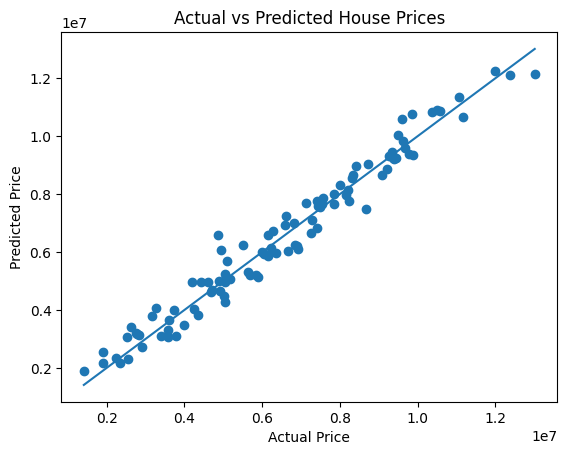

In [34]:
plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [35]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions.astype(int)
})

print(results.head(10))

   Actual Price  Predicted Price
0       2551339          2293959
1       3602200          3643941
2       3735900          3984206
3       5683051          5223800
4      11067838         11342012
5       9216605          8867183
6       8345151          8665866
7      11168925         10678513
8       7273547          7092534
9       9072046          8643856


In [36]:
results["Error"] = (
    results["Actual Price"] -
    results["Predicted Price"]
)

In [37]:
results.head(10)

,Actual Price,Predicted Price,Error
0,2551339,2293959,257380
1,3602200,3643941,-41741
2,3735900,3984206,-248306
3,5683051,5223800,459251
4,11067838,11342012,-274174
5,9216605,8867183,349422
6,8345151,8665866,-320715
7,11168925,10678513,490412
8,7273547,7092534,181013
9,9072046,8643856,428190


In [39]:
residuals = y_test - predictions
results["Residual"] = (
    results["Actual Price"] -
    results["Predicted Price"]
)

print(results.head(10))

   Actual Price  Predicted Price   Error  Residual
0       2551339          2293959  257380    257380
1       3602200          3643941  -41741    -41741
2       3735900          3984206 -248306   -248306
3       5683051          5223800  459251    459251
4      11067838         11342012 -274174   -274174
5       9216605          8867183  349422    349422
6       8345151          8665866 -320715   -320715
7      11168925         10678513  490412    490412
8       7273547          7092534  181013    181013
9       9072046          8643856  428190    428190


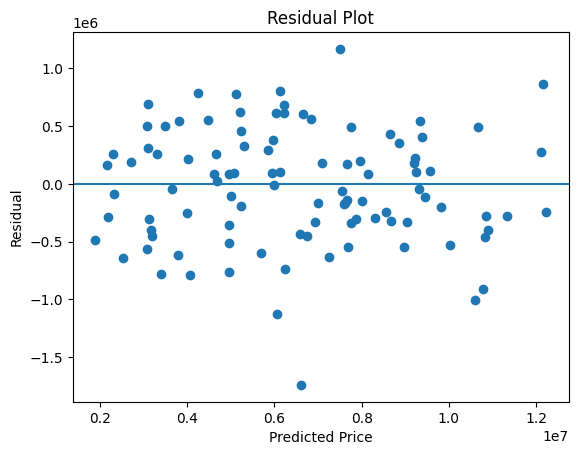

In [40]:
plt.scatter(predictions, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [42]:
from sklearn.model_selection import cross_val_score

In [43]:
cv = cross_val_score(model , X_train , y_train , cv = 5 , scoring = "r2")

In [44]:
cv

array([0.9636961 , 0.95029708, 0.95488871, 0.950677  , 0.96993528])

In [45]:
cv.mean()

np.float64(0.9578988345678858)

In [46]:
model.fit(X_train, y_train)

LinearRegression()

In [47]:
new_house = pd.DataFrame({
    "area_sqft": [2000],
    "bedrooms": [3],
    "bathrooms": [2],
    "age_years": [5]
})

In [50]:
predicted_price = model.predict(new_house)[0]

In [51]:
predicted_price

np.float64(8132794.82665021)

In [52]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')